<a href="https://colab.research.google.com/github/stfnnnnnnn/karl-mangahas-flyrank/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/stfnnnnnnn/1st-act/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

>I use the audited model score to rank pages by **which pages should be reviewed first**. A higher score does not mean that a page must be refreshed or that it will definitely decline. It means the page has a higher estimated decline risk based on the historical signals available before the outcome window.

>My final leakage-safe predictors are `imp_prev30`, `clk_prev30`, and `pos_prev30`. The outcome is `is_declining = 1` when impressions in the later 30-day window fall below 80% of impressions in the previous 30-day window. I removed `pos_last30` after the Week 6 audit because it came from the same period used to define the outcome.

>This notebook recomputes the transparent baseline, Logistic Regression, and Random Forest on the **same client-grouped split**. The same-run results below are the canonical Week 7 playbook metrics. I retain the more complex model only when it improves the review ranking enough to justify the added complexity.

>Precision@20 and Precision@50 are the main decision metrics because they match realistic limited review capacity. ROC-AUC and Average Precision remain supporting measures.

### How I turn the ranking into actions

The following **review archetypes are transparent policy categories, not learned clusters**. They translate model rank and observable review signals into practical workflow states.

| Review archetype | What I see | Suggested action | Why |
|---|---|---|---|
| High-value risk | High model rank + strong prior visibility | **Review now** | A possible decline matters more when the page already has meaningful exposure. |
| Page-one watch | High model rank + prior position 1–10 | **Protect and diagnose** | A strong-ranking page has value to protect, so diagnosis should come before large edits. |
| Click-capture opportunity | Enough impressions + position 1–20 + weak prior CTR | **Review click capture** | The page is visible but may be under-capturing clicks; title, snippet, and intent deserve inspection. |
| Low-evidence risk | High score but low prior impressions | **Monitor** | Low volume makes the signal less reliable and increases the chance of noise. |
| Lower-priority page | Does not meet a stronger review pattern | **Standard review / monitor** | The model alone is not enough to justify urgent editorial work. |

>The queue uses reason codes such as `top50_model_rank`, `high_model_rank`, `visible_at_risk`, `page_one_watch`, `low_click_capture`, and `thin_evidence`. These codes are **not causes**. They explain why a page was surfaced and what a reviewer should inspect next.

>The known holdout outcome is retained only for retrospective evaluation. It is excluded from the reviewer-facing action queue because that future outcome would not be available when the review decision is made.

### Decay and refresh insight

>The **FlyRank research paper audited in Week 6** reported an observed relationship between freshness and performance, including a favorable 31–90 day freshness band and large measured differences between recently refreshed and less-recently updated mature pages.

>I use that finding as **review context, not as proof that refreshing a page causes recovery**. Refresh assignment may reflect pre-existing differences between pages. A high-ranked page therefore requires diagnosis before a reviewer chooses refresh, protection, expansion, consolidation, or monitoring.

>The operational implication is deliberately narrow: **freshness can help inform what a human inspects, but it does not determine what the human should change.**

In [10]:
# Rebuild the leakage-safe March frame and compare baseline, Logistic Regression, and Random Forest.
%pip -q install duckdb huggingface_hub

import os, getpass, json, platform
import numpy as np
import pandas as pd
from pathlib import Path
import duckdb
import sklearn

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import roc_auc_score, average_precision_score

RANDOM_SEED = 42

HF_TOKEN = os.environ.get("HF_TOKEN")

if not HF_TOKEN:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get("HF_TOKEN")
    except Exception:
        pass

HF_TOKEN = HF_TOKEN or getpass.getpass("HF token: ")

con = duckdb.connect()

con.execute(f"""
CREATE OR REPLACE SECRET hf (
    TYPE huggingface,
    TOKEN '{HF_TOKEN}'
)
""")

REL = "hf://datasets/FlyRank/internship-warehouse"
FACT = f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')"

features = con.sql(f"""
WITH bounds AS (
    SELECT MAX(report_date) AS end_d
    FROM {FACT}
    WHERE month = '2026-03'
),
windowed AS (
    SELECT
        f.client_hash_id,
        f.content_hash_id,
        SUM(
            CASE WHEN f.report_date > b.end_d - INTERVAL 30 DAY
            THEN f.gsc_impressions ELSE 0 END
        ) AS imp_last30,
        SUM(
            CASE WHEN f.report_date <= b.end_d - INTERVAL 30 DAY
            THEN f.gsc_impressions ELSE 0 END
        ) AS imp_prev30,
        SUM(
            CASE WHEN f.report_date <= b.end_d - INTERVAL 30 DAY
            THEN f.gsc_clicks ELSE 0 END
        ) AS clk_prev30,
        AVG(
            CASE WHEN f.report_date <= b.end_d - INTERVAL 30 DAY
            THEN f.gsc_avg_position END
        ) AS pos_prev30
    FROM {FACT} f, bounds b
    WHERE
        f.report_date > b.end_d - INTERVAL 60 DAY
        AND f.report_date <= b.end_d
    GROUP BY f.client_hash_id, f.content_hash_id
    HAVING imp_prev30 >= 100
)
SELECT * FROM windowed
""").df()

features["is_declining"] = (
    features["imp_last30"] < 0.8 * features["imp_prev30"]
).astype(int)

features["ctr_prev30"] = np.where(
    features["imp_prev30"] > 0,
    100 * features["clk_prev30"] / features["imp_prev30"],
    np.nan,
)

SAFE_FEATURES = ["imp_prev30", "clk_prev30", "pos_prev30"]

X = features[SAFE_FEATURES].copy()
X["pos_prev30"] = X["pos_prev30"].fillna(0)

y = features["is_declining"].copy()
groups = features["client_hash_id"]

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.25,
    random_state=RANDOM_SEED,
)

tr_g, te_g = next(gss.split(X, y, groups))

train_clients = set(groups.iloc[tr_g])
test_clients = set(groups.iloc[te_g])

assert len(train_clients & test_clients) == 0


def precision_at_k(y_true, scores, k):
    k = min(k, len(scores))
    order = np.argsort(-np.asarray(scores))[:k]
    return float(np.asarray(y_true)[order].mean())


def ranking_metrics(name, y_true, scores):
    return {
        "method": name,
        "test_base_rate": float(np.mean(y_true)),
        "roc_auc": float(roc_auc_score(y_true, scores)),
        "average_precision": float(
            average_precision_score(y_true, scores)
        ),
        "precision_at_20": precision_at_k(y_true, scores, 20),
        "precision_at_50": precision_at_k(y_true, scores, 50),
    }


test_frame = features.iloc[te_g].copy()

baseline_scores = np.where(
    (test_frame["imp_prev30"] >= 300)
    & (test_frame["pos_prev30"].fillna(0) > 10),
    test_frame["imp_prev30"],
    0.0,
)

logit = Pipeline([
    ("scale", StandardScaler()),
    (
        "model",
        LogisticRegression(
            max_iter=2000,
            random_state=RANDOM_SEED,
        ),
    ),
])

logit.fit(X.iloc[tr_g], y.iloc[tr_g])
prob_logit = logit.predict_proba(X.iloc[te_g])[:, 1]

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_SEED,
    n_jobs=-1,
)

rf.fit(X.iloc[tr_g], y.iloc[tr_g])
prob_rf = rf.predict_proba(X.iloc[te_g])[:, 1]

yt = y.iloc[te_g].to_numpy()

comparison = pd.DataFrame([
    ranking_metrics(
        "Audited transparent baseline",
        yt,
        baseline_scores,
    ),
    ranking_metrics(
        "Logistic Regression",
        yt,
        prob_logit,
    ),
    ranking_metrics(
        "Random Forest",
        yt,
        prob_rf,
    ),
])

display(
    comparison.style.format({
        "test_base_rate": "{:.2%}",
        "roc_auc": "{:.3f}",
        "average_precision": "{:.3f}",
        "precision_at_20": "{:.2%}",
        "precision_at_50": "{:.2%}",
    })
)

print("Rows:", f"{len(features):,}")
print("Clients:", groups.nunique())
print("Grouped test rows:", f"{len(te_g):,}")
print("Test clients:", groups.iloc[te_g].nunique())
print("Train/test client overlap:", len(train_clients & test_clients))
print("Random seed:", RANDOM_SEED)

print(
    "Versions:",
    {
        "python": platform.python_version(),
        "pandas": pd.__version__,
        "sklearn": sklearn.__version__,
        "duckdb": duckdb.__version__,
    },
)

prob = prob_rf

metrics = (
    comparison
    .set_index("method")
    .loc["Random Forest"]
    .to_dict()
)

metrics.update({
    "test_rows": int(len(te_g)),
    "test_clients": int(groups.iloc[te_g].nunique()),
})

baseline_eligible = (
    (test_frame["imp_prev30"] >= 300)
    & (test_frame["pos_prev30"].fillna(0) > 10)
)

print(
    "Baseline-eligible pages:",
    f"{baseline_eligible.sum():,}",
    f"({baseline_eligible.mean():.2%} of grouped holdout)",
)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,method,test_base_rate,roc_auc,average_precision,precision_at_20,precision_at_50
0,Audited transparent baseline,25.96%,0.479,0.251,5.00%,6.00%
1,Logistic Regression,25.96%,0.532,0.263,40.00%,28.00%
2,Random Forest,25.96%,0.532,0.282,45.00%,40.00%


Rows: 82,025
Clients: 37
Grouped test rows: 26,184
Test clients: 10
Train/test client overlap: 0
Random seed: 42
Versions: {'python': '3.12.13', 'pandas': '2.2.2', 'sklearn': '1.6.1', 'duckdb': '1.3.2'}
Baseline-eligible pages: 3,086 (11.79% of grouped holdout)


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

### Intended use

>The intended users are **content managers and editors who cannot manually inspect every page**. The playbook helps allocate limited review capacity by ranking pseudonymized pages from higher to lower review priority. One row in the queue represents one content page.

>The queue is a **decision-support tool**, not an automated editorial system. A reviewer can start with the top 20 or top 50 pages, inspect the reason codes and available context, and then decide whether to investigate, act, monitor, or dismiss the recommendation. The model score determines **review order**; it does not determine the final editorial action.

>The review archetypes are **transparent policy categories, not learned clusters**. They translate model rank and observable signals into practical review states. The known holdout outcome is used only for retrospective evaluation and is excluded from the reviewer-facing action queue because it would not be available at decision time.

### Limits

>The model only sees three leakage-audited prior-window search signals: **impressions, clicks, and average position**. It does **not** know the page's full content quality, business importance, search intent, query mix, seasonality, competing pages, recent edits, SERP changes, or client-specific events. These missing factors can make a high-ranked recommendation wrong.

>The March analysis is a **development evaluation using a client-grouped holdout**. Testing on unseen clients is more realistic than a random row split, but it is not the same as a sealed future-month deployment test. The measured performance should therefore not be assumed to hold across every future month or client.

>The decline label is an observational outcome: later impressions fell by more than 20% relative to the previous window. It identifies **what happened, not why it happened**. A decline may reflect genuine decay, but it may also reflect seasonality, consolidation, SERP changes, broader site movement, or noise.

>The label also does not show that editing a flagged page would reverse the decline. The safest claim is therefore:

* **The model provides directional decision support for prioritizing which pages appear worth reviewing first based on historical search signals.**

* It does not predict Google's algorithm, diagnose the cause of decline, or guarantee that a content change will improve performance.

### Cost and value

>The practical cost of a **high-ranked actual negative** is wasted review time or an unnecessary change to a page that did not meet the observed decline outcome. The cost of a **low-ranked actual positive** is missing a page that later declines and therefore receives no early review.

>These costs are not equal for every page. Changing an already strong page can carry greater downside than monitoring a low-volume page, which is why the playbook includes conservative actions such as `protect_and_diagnose` and `monitor`.

>Because review capacity is limited, **Precision@20 and Precision@50** matter more to this use case than assigning every page the correct binary label. The learned model should be retained only when it improves ranking at the review capacity that matters. If that advantage disappears during later validation, the simpler transparent baseline should be preferred.

>I do not convert these errors into invented financial values because the data does not establish the monetary return from an editorial intervention. Here, value is operational: **concentrate limited review capacity where the evidence is strongest while keeping consequential editorial actions under human control.**

### Same-run model comparison

>The table above is the **canonical Week 7 comparison** because all methods are recomputed in the same notebook run using the same population and client-grouped holdout.

>I do not select a metric simply because it is higher than an earlier result. If a Week 6 number differs from this rerun, I treat that difference as a reproducibility question and use the current documented execution and metrics receipt for the playbook and paper.

>The transparent baseline uses a minimum of 300 prior-window impressions and prior average position worse than 10. These are **review-policy thresholds, not universal SEO rules**. Their purpose is to create a simple comparator that reduces low-volume noise and can be evaluated on exactly the same holdout as the learned models.

>Additional model complexity is useful only if it improves the ranking at the review capacity that matters.

In [12]:
eval_queue = features.iloc[te_g][[
    "client_hash_id",
    "content_hash_id",
    "imp_prev30",
    "clk_prev30",
    "ctr_prev30",
    "pos_prev30",
    "is_declining",
]].copy()

eval_queue = eval_queue.rename(
    columns={"is_declining": "observed_holdout_outcome"}
)

eval_queue["model_score"] = prob

eval_queue = (
    eval_queue
    .sort_values(
        ["model_score", "imp_prev30"],
        ascending=[False, False],
    )
    .reset_index(drop=True)
)

eval_queue.insert(
    0,
    "rank",
    np.arange(1, len(eval_queue) + 1),
)

eval_queue["model_percentile"] = (
    1 - (eval_queue["rank"] - 1) / len(eval_queue)
)

queue = eval_queue.drop(
    columns=["observed_holdout_outcome"]
).copy()


def reason_codes(r):
    codes = []

    if r["rank"] <= 50:
        codes.append("top50_model_rank")

    if r["model_percentile"] >= 0.90:
        codes.append("high_model_rank")

    if (
        r["imp_prev30"] >= 1000
        and r["model_percentile"] >= 0.90
    ):
        codes.append("visible_at_risk")

    if (
        pd.notna(r["pos_prev30"])
        and 0 < r["pos_prev30"] <= 10
        and r["model_percentile"] >= 0.90
    ):
        codes.append("page_one_watch")

    if (
        r["imp_prev30"] >= 500
        and pd.notna(r["pos_prev30"])
        and 0 < r["pos_prev30"] <= 20
        and r["ctr_prev30"] < 0.5
    ):
        codes.append("low_click_capture")

    if r["imp_prev30"] < 250:
        codes.append("thin_evidence")

    return ";".join(codes) if codes else "model_rank_only"


def action(r):
    codes = set(r["reason_codes"].split(";"))

    if "thin_evidence" in codes:
        return "monitor"

    if "page_one_watch" in codes:
        return "protect_and_diagnose"

    if (
        "low_click_capture" in codes
        and "high_model_rank" in codes
    ):
        return "review_click_capture"

    if (
        "top50_model_rank" in codes
        and "visible_at_risk" in codes
    ):
        return "review_now"

    return "standard_review"


def archetype(r):
    codes = set(r["reason_codes"].split(";"))

    if "thin_evidence" in codes:
        return "low-evidence risk"

    if "page_one_watch" in codes:
        return "page-one watch"

    if (
        "low_click_capture" in codes
        and "high_model_rank" in codes
    ):
        return "click-capture opportunity"

    if "visible_at_risk" in codes:
        return "high-value risk"

    return "lower-priority"


def confidence_note(r):
    if r["imp_prev30"] < 250:
        return "low evidence: limited prior volume"

    if r["rank"] <= 50:
        return "top-capacity candidate; still requires diagnosis"

    if r["model_percentile"] >= 0.90:
        return (
            "high model rank; not a calibrated impact probability"
        )

    return "ranking context only"


def wrong_if(r):
    if (
        pd.notna(r["pos_prev30"])
        and 0 < r["pos_prev30"] <= 10
    ):
        return (
            "seasonality, consolidation, or a temporary demand "
            "shift explains the risk; aggressive edits could harm "
            "a strong page"
        )

    if r["imp_prev30"] < 250:
        return "the apparent pattern is low-volume noise"

    return (
        "seasonality, cannibalization, SERP change, or "
        "client-specific context explains the movement"
    )


queue["reason_codes"] = queue.apply(reason_codes, axis=1)
queue["suggested_action"] = queue.apply(action, axis=1)
queue["archetype"] = queue.apply(archetype, axis=1)
queue["confidence_note"] = queue.apply(confidence_note, axis=1)

queue["what_would_make_it_wrong"] = queue.apply(
    wrong_if,
    axis=1,
)

queue["human_review_required"] = True

assert "is_declining" not in queue.columns
assert "observed_holdout_outcome" not in queue.columns

display(queue.head(20))

print("Top 20 action mix:")
display(
    queue.head(20)["suggested_action"]
    .value_counts()
    .rename("pages")
    .to_frame()
)

print("Top 50 action mix:")
display(
    queue.head(50)["suggested_action"]
    .value_counts()
    .rename("pages")
    .to_frame()
)

,rank,client_hash_id,content_hash_id,imp_prev30,clk_prev30,ctr_prev30,pos_prev30,model_score,model_percentile,reason_codes,suggested_action,archetype,confidence_note,what_would_make_it_wrong,human_review_required
0,1,client_a80fca3f171ed1de,content_026e6d5b107918ee,2229.0,0.0,0.000000,7.969647,0.960000,1.000000,top50_model_rank;high_model_rank;visible_at_ri...,protect_and_diagnose,page-one watch,top-capacity candidate; still requires diagnosis,"seasonality, consolidation, or a temporary dem...",True
1,2,client_62f4a7e64f5e0096,content_5ff17f73dc7e583e,366.0,0.0,0.000000,0.459472,0.960000,0.999962,top50_model_rank;high_model_rank;page_one_watch,protect_and_diagnose,page-one watch,top-capacity candidate; still requires diagnosis,"seasonality, consolidation, or a temporary dem...",True
2,3,client_65de48885f4ef01b,content_d4fa03e9112bc1dc,191.0,0.0,0.000000,10.780908,0.956667,0.999924,top50_model_rank;high_model_rank;thin_evidence,monitor,low-evidence risk,low evidence: limited prior volume,the apparent pattern is low-volume noise,True
3,4,client_62f4a7e64f5e0096,content_46446e5e2a0d70af,161.0,0.0,0.000000,2.962275,0.956667,0.999885,top50_model_rank;high_model_rank;page_one_watc...,monitor,low-evidence risk,low evidence: limited prior volume,"seasonality, consolidation, or a temporary dem...",True
4,5,client_62f4a7e64f5e0096,content_ed1b332b1cf85f2b,1256.0,0.0,0.000000,0.294339,0.950000,0.999847,top50_model_rank;high_model_rank;visible_at_ri...,protect_and_diagnose,page-one watch,top-capacity candidate; still requires diagnosis,"seasonality, consolidation, or a temporary dem...",True
5,6,client_fef1a8f436438636,content_0fc93224cf2ba5f0,165.0,0.0,0.000000,47.680490,0.946667,0.999809,top50_model_rank;high_model_rank;thin_evidence,monitor,low-evidence risk,low evidence: limited prior volume,the apparent pattern is low-volume noise,True
6,7,client_65de48885f4ef01b,content_6eea5f347d933768,100.0,0.0,0.000000,8.771501,0.940000,0.999771,top50_model_rank;high_model_rank;page_one_watc...,monitor,low-evidence risk,low evidence: limited prior volume,"seasonality, consolidation, or a temporary dem...",True
7,8,client_fef1a8f436438636,content_55184d9c3962a8f0,252.0,0.0,0.000000,28.392392,0.930000,0.999733,top50_model_rank;high_model_rank,standard_review,lower-priority,top-capacity candidate; still requires diagnosis,"seasonality, cannibalization, SERP change, or ...",True
8,9,client_62f4a7e64f5e0096,content_408e68118e175bc4,100.0,0.0,0.000000,5.544444,0.930000,0.999694,top50_model_rank;high_model_rank;page_one_watc...,monitor,low-evidence risk,low evidence: limited prior volume,"seasonality, consolidation, or a temporary dem...",True
9,10,client_65de48885f4ef01b,content_d3deb25effd3253f,100.0,0.0,0.000000,5.603492,0.930000,0.999656,top50_model_rank;high_model_rank;page_one_watc...,monitor,low-evidence risk,low evidence: limited prior volume,"seasonality, consolidation, or a temporary dem...",True


Top 20 action mix:


,pages
suggested_action,
monitor,13
protect_and_diagnose,6
standard_review,1


Top 50 action mix:


,pages
suggested_action,
monitor,24
protect_and_diagnose,19
standard_review,6
review_click_capture,1


## 3. Human review + the no-go list

*What a reviewer must check before acting, and what should never be automated.*

### Human-review rules

Before acting on a recommendation, the reviewer should ask:

1. **Is there enough evidence?** Low-volume pages may reflect noise rather than meaningful movement.
2. **Is the movement persistent?** A short-lived drop should not automatically trigger editorial work.
3. **Could something else explain the movement?** Seasonality, consolidation, site-wide shifts, SERP changes, or related pages may explain the observed risk.
4. **Does the page still satisfy its intended search need?** The model cannot inspect the content itself or determine whether intent is still being met.
5. **Would editing create protection risk?** Strong-ranking pages should be diagnosed carefully before major changes.
6. **What was the final human decision?** Record `act`, `monitor`, or `dismiss` with a short reason so the usefulness of the queue can be evaluated later.

### What the ranking errors tell me

>The audited model still makes consequential ranking mistakes. Because this is a ranking task, I focus on **high-scored actual negatives** and **low-scored actual positives** rather than imposing an arbitrary classification threshold.

>A high-scored actual negative may consume limited review capacity even though it did not meet the observed decline outcome. A low-scored actual positive represents a declining page the ranking may fail to surface early.

These examples show why the three-feature model should be used to prioritize investigation rather than diagnose individual pages.

### What should NOT be automated

I would **not** allow this model to automatically:

- publish or rewrite content;
- refresh a page solely because its score is high;
- delete or prune a page;
- merge pages or create redirects;
- change titles or metadata;
- declare that a page declined because it was stale, thin, or poorly optimized;
- treat low CTR as proof that the title or meta description is bad;
- treat a high model score as proof that an edit will improve traffic.

>The safe automation boundary is narrower: the system may **recompute leakage-safe scores, rank pseudonymized pages, attach reason codes, and prepare a review queue**. The editorial decision remains with a person.

In [13]:
# Inspect concrete errors from the audited grouped holdout.
errors = eval_queue.copy()

highest_scored_negatives = (
    errors[
        errors["observed_holdout_outcome"] == 0
    ]
    .sort_values("model_score", ascending=False)
)

lowest_scored_positives = (
    errors[
        errors["observed_holdout_outcome"] == 1
    ]
    .sort_values("model_score", ascending=True)
)

print("Three highest-scored actual negatives:")
display(highest_scored_negatives.head(3))

print("Three lowest-scored actual positives:")
display(lowest_scored_positives.head(3))

importance = (
    pd.Series(
        rf.feature_importances_,
        index=SAFE_FEATURES,
    )
    .sort_values(ascending=False)
)

print("Random Forest feature importances:")
display(
    importance
    .rename("importance")
    .to_frame()
)

for k in [20, 50, 100]:
    print(f"Top {k} action mix:")
    display(
        queue.head(k)["suggested_action"]
        .value_counts()
        .rename("pages")
        .to_frame()
    )


Three highest-scored actual negatives:


,rank,client_hash_id,content_hash_id,imp_prev30,clk_prev30,ctr_prev30,pos_prev30,observed_holdout_outcome,model_score,model_percentile
4,5,client_62f4a7e64f5e0096,content_ed1b332b1cf85f2b,1256.0,0.0,0.0,0.294339,0,0.950000,0.999847
5,6,client_fef1a8f436438636,content_0fc93224cf2ba5f0,165.0,0.0,0.0,47.680490,0,0.946667,0.999809
9,10,client_65de48885f4ef01b,content_d3deb25effd3253f,100.0,0.0,0.0,5.603492,0,0.930000,0.999656


Three lowest-scored actual positives:


,rank,client_hash_id,content_hash_id,imp_prev30,clk_prev30,ctr_prev30,pos_prev30,observed_holdout_outcome,model_score,model_percentile
26180,26181,client_62f4a7e64f5e0096,content_1fe8a8a4e913881f,178.0,0.0,0.000000,5.306667,1,0.0,0.000153
26179,26180,client_62f4a7e64f5e0096,content_7f0267173a27b951,1840.0,0.0,0.000000,26.709075,1,0.0,0.000191
26177,26178,client_fef1a8f436438636,content_d175d629ceb343d4,5934.0,20.0,0.337041,12.589067,1,0.0,0.000267


Random Forest feature importances:


...

,pages
suggested_action,
monitor,13
protect_and_diagnose,6
standard_review,1


Top 50 action mix:


,pages
suggested_action,
monitor,24
protect_and_diagnose,19
standard_review,6
review_click_capture,1


Top 100 action mix:


,pages
suggested_action,
monitor,49
protect_and_diagnose,39
standard_review,11
review_click_capture,1


## 4. Monitoring / retrain triggers

*What would tell me the recommendations have gone stale?*

>Monitoring stays light because this is a **research prototype, not a production system**. The main question is whether the ranking continues to help reviewers prioritize pages better than the contemporary base rate and transparent baseline.

For each new evaluation window, I would track:

- Precision@20;
- Precision@50;
- Average Precision;
- ROC-AUC;
- current decline base rate;
- eligible pages and clients;
- model-score distribution;
- feature distributions;
- reason-code and action mix; and
- recorded reviewer decisions.

I would revalidate or retrain when:

- Precision@20 or Precision@50 falls close to the contemporary base rate;
- Average Precision no longer shows useful lift over the base rate;
- the transparent baseline performs as well as or better than the learned model;
- impressions, clicks, position, or score distributions change materially;
- the client or page population changes substantially;
- the feature window or decline definition changes; or
- a new feature is introduced.

>Any new feature requires another leakage audit before an apparent improvement is trusted. I would also investigate an implausibly strong top-K result rather than automatically celebrating it.

>I would **not retrain on a fixed schedule simply for the sake of retraining**. Retraining should follow new labeled evidence, meaningful drift, or a material change in the problem definition.

In [14]:
# Light monitoring policy: these are review triggers, not formal drift-test thresholds.
monitoring_policy = {
    "headline_metric": "Precision@K",
    "review_capacity_k": [20, 50],
    "compare_against": [
        "current base rate",
        "audited transparent baseline",
        "Logistic Regression",
    ],
    "revalidate_if_precision_at_k_near_base_rate": True,
    "revalidate_if_average_precision_near_base_rate": True,
    "re_audit_on_feature_or_window_change": True,
    "investigate_implausibly_perfect_top_k": True,
    "prefer_simpler_model_if_complexity_not_earned": True,
    "autonomous_actions_allowed": False,
}

monitoring_policy


{'headline_metric': 'Precision@K',
 'review_capacity_k': [20, 50],
 'compare_against': ['current base rate',
  'audited transparent baseline',
  'Logistic Regression'],
 'revalidate_if_precision_at_k_near_base_rate': True,
 'revalidate_if_average_precision_near_base_rate': True,
 're_audit_on_feature_or_window_change': True,
 'investigate_implausibly_perfect_top_k': True,
 'prefer_simpler_model_if_complexity_not_earned': True,
 'autonomous_actions_allowed': False}

## 5. Exports for the paper

*The paper should be able to trace its recommendations and numbers back to this notebook.*

This notebook exports:

- `work/outputs/w07_ranked_action_queue.csv` — the **decision-time-safe human-review queue** containing scores, reason codes, review archetypes, suggested actions, confidence notes, and human-review requirements. The future holdout outcome is deliberately excluded.
- `work/outputs/w07_model_comparison.csv` — the same-run comparison of the transparent baseline, Logistic Regression, and Random Forest.
- `work/outputs/w07_playbook_metrics.json` — the metrics and reproducibility receipt used to trace paper claims.
- `work/figures/w07_precision_at_k.png` — a reusable comparison of Precision@K against the baseline and grouped-test base rate.

### Final recommendation

>I recommend using the model as a **small, ranked human-review queue**, beginning with the number of pages the editorial team can realistically inspect, such as the top 20 or top 50.

>High-ranked pages with enough evidence deserve earlier diagnosis, while low-volume cases should generally be monitored rather than acted on immediately. A strong page may need protection, a visible page with weak click capture may deserve snippet and intent review, and some recommendations may appropriately be dismissed after human inspection.

>Refresh is **one possible action, not the default action**.

The conclusion I carry into the paper is:

>**Historical search signals provide measured, directional value for ordering a limited review queue, but the audited model is not evidence for autonomous editorial decisions.**

>Its practical value is in focusing attention, explaining why pages were surfaced, and making limited human review more systematic.

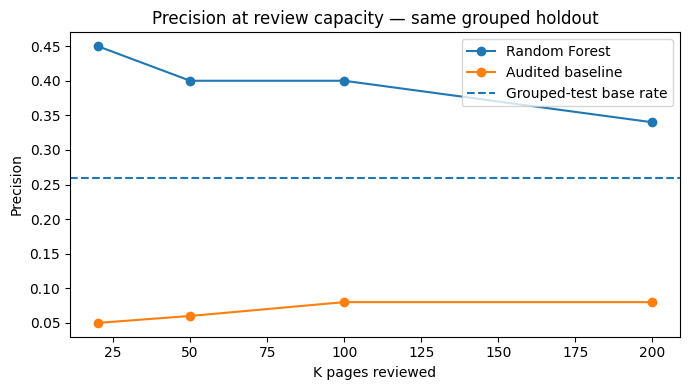

Queue: work/outputs/w07_ranked_action_queue.csv
Metrics receipt: work/outputs/w07_playbook_metrics.json
Comparison CSV: work/outputs/w07_model_comparison.csv
Figure: work/figures/w07_precision_at_k.png
Exported queue rows: 26,184
Future/outcome columns in queue: []


In [15]:
import matplotlib.pyplot as plt

OUT = Path("work/outputs")
FIG = Path("work/figures")

OUT.mkdir(parents=True, exist_ok=True)
FIG.mkdir(parents=True, exist_ok=True)

queue_path = OUT / "w07_ranked_action_queue.csv"
metrics_path = OUT / "w07_playbook_metrics.json"
comparison_path = OUT / "w07_model_comparison.csv"
fig_path = FIG / "w07_precision_at_k.png"

FORBIDDEN_QUEUE_COLUMNS = {
    "is_declining",
    "observed_holdout_outcome",
    "trend_direction",
    "trend_pct",
    "imp_last30",
    "clk_last30",
    "pos_last30",
}

unexpected = FORBIDDEN_QUEUE_COLUMNS.intersection(
    queue.columns
)

assert not unexpected, (
    "Future/outcome columns found in action queue: "
    f"{sorted(unexpected)}"
)

queue.to_csv(queue_path, index=False)
comparison.to_csv(comparison_path, index=False)

receipt = {
    "comparison": comparison.to_dict(orient="records"),
    "feature_set": SAFE_FEATURES,
    "validation": (
        "GroupShuffleSplit by client_hash_id, "
        "test_size=0.25, random_state=42"
    ),
    "validation_scope": (
        "Client-grouped March development evaluation; "
        "not a sealed future-month deployment test."
    ),
    "label": "imp_last30 < 0.8 * imp_prev30",
    "baseline": (
        "imp_prev30 >= 300 and pos_prev30 > 10; "
        "rank eligible pages by imp_prev30"
    ),
    "random_seed": RANDOM_SEED,
    "versions": {
        "python": platform.python_version(),
        "pandas": pd.__version__,
        "sklearn": sklearn.__version__,
        "duckdb": duckdb.__version__,
    },
    "rf_parameters": rf.get_params(),
    "rf_feature_importance": {
        k: float(v)
        for k, v in importance.items()
    },
    "queue_scope": (
        "Human-review decision-support queue using "
        "pre-outcome signals; future outcomes excluded."
    ),
    "archetype_definition": (
        "Transparent rule-based review categories; "
        "not learned clusters."
    ),
    "intended_use": (
        "Rank pseudonymized pages for human review."
    ),
    "not_for": [
        "automatic editing or publishing",
        "causal refresh claims",
        "Google algorithm claims",
        "production autonomous decisions",
    ],
}

metrics_path.write_text(
    json.dumps(receipt, indent=2)
)

ks = [20, 50, 100, 200]

rf_vals = [
    precision_at_k(yt, prob_rf, k)
    for k in ks
]

baseline_vals = [
    precision_at_k(yt, baseline_scores, k)
    for k in ks
]

plt.figure(figsize=(7, 4))

plt.plot(
    ks,
    rf_vals,
    marker="o",
    label="Random Forest",
)

plt.plot(
    ks,
    baseline_vals,
    marker="o",
    label="Audited baseline",
)

plt.axhline(
    float(np.mean(yt)),
    linestyle="--",
    label="Grouped-test base rate",
)

plt.xlabel("K pages reviewed")
plt.ylabel("Precision")
plt.title(
    "Precision at review capacity — same grouped holdout"
)
plt.legend()
plt.tight_layout()
plt.savefig(fig_path, dpi=160)
plt.show()

print("Queue:", queue_path)
print("Metrics receipt:", metrics_path)
print("Comparison CSV:", comparison_path)
print("Figure:", fig_path)
print("Exported queue rows:", f"{len(queue):,}")
print(
    "Future/outcome columns in queue:",
    sorted(unexpected),
)

## Self-check

Before you submit, confirm each line honestly:

- [ - ] Every section above is filled — markdown thinking AND the code that backs it
- [ - ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ - ] No client names, URLs, or private queries anywhere
- [ - ] My claims use careful words: observed, measured, directional, decision-support
- [ - ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.